# 🛡️ Network Intrusion Detection System — ML Training Pipeline

This notebook trains and compares multiple classifiers on the **CICIDS2017** dataset to distinguish benign network traffic from attacks. It profiles each model on the critical deployment trade-off: **detection accuracy vs. inference latency**. The best-performing model is exported for use in the live dashboard.

---

## Phase 0: Environment Setup and Imports

### Step 1: Import Libraries

Import all required libraries: `pandas`, `numpy`, `scikit-learn`, `xgboost`, `matplotlib`, timing utilities, and `joblib`.

In [2]:
import os
import glob
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "xgboost is required for this notebook. Install it with: pip install xgboost"
    ) from exc

import joblib

warnings.filterwarnings('ignore')

print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"xgboost:      {xgb.__version__}")
print(f"joblib:       {joblib.__version__}")
print("\n✅ All libraries loaded successfully.")

pandas:       2.3.3
numpy:        2.4.2
scikit-learn: 1.8.0
xgboost:      3.2.0
joblib:       1.5.3

✅ All libraries loaded successfully.


### ⏸️ Checkpoint 0

**Wait for confirmation** that all libraries loaded without errors before proceeding.

---
## Phase 1: Data Acquisition and Feature Reduction

### Step 1: Load the CICIDS2017 Dataset

Load **all CSV files** from the `data/` directory and concatenate them into a single DataFrame. The dataset ships as multiple day-files.

In [3]:
DATA_DIR = os.path.join('..', 'data')

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  • {os.path.basename(f)}")

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found in '{os.path.abspath(DATA_DIR)}'.\n"
        "Download CICIDS2017 MachineLearningCSV.zip and extract into the data/ folder."
    )

# Load and concatenate all CSVs
dfs = []
for f in csv_files:
    print(f"Loading {os.path.basename(f)}...", end=" ")
    chunk = pd.read_csv(f, encoding='utf-8', low_memory=False)
    print(f"({len(chunk):,} rows)")
    dfs.append(chunk)

df_raw = pd.concat(dfs, ignore_index=True)

# CRITICAL: Strip whitespace from column names (CICIDS2017 has leading spaces)
df_raw.columns = df_raw.columns.str.strip()

print(f"\n📊 Total dataset shape: {df_raw.shape}")
print(f"   Columns: {list(df_raw.columns[:10])}... ({len(df_raw.columns)} total)")

Found 8 CSV files:
  • Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  • Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  • Friday-WorkingHours-Morning.pcap_ISCX.csv
  • Monday-WorkingHours.pcap_ISCX.csv
  • Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  • Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  • Tuesday-WorkingHours.pcap_ISCX.csv
  • Wednesday-workingHours.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv... (225,745 rows)
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv... (286,467 rows)
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv... (191,033 rows)
Loading Monday-WorkingHours.pcap_ISCX.csv... (529,918 rows)
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv... (288,602 rows)
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv... (170,366 rows)
Loading Tuesday-WorkingHours.pcap_ISCX.csv... (445,909 rows)
Loading Wednesday-workingHours.pcap_ISCX.csv... (692,703 rows)

📊 Total da

### Step 2: 🔑 Feature Reduction (CRITICAL)

Select **only** the 7 features that can be realistically computed from raw packets in real-time:

| # | Feature | Why it's extractable in real-time |
|---|---------|-----------------------------------|
| 1 | `Destination Port` | Directly from TCP header |
| 2 | `Total Fwd Packets` | Count packets src→dst |
| 3 | `Total Backward Packets` | Count packets dst→src |
| 4 | `Fwd Packet Length Mean` | Mean payload size (forward) |
| 5 | `Bwd Packet Length Mean` | Mean payload size (backward) |
| 6 | `SYN Flag Count` | Count SYN flags in TCP header |
| 7 | `ACK Flag Count` | Count ACK flags in TCP header |

In [4]:
SELECTED_FEATURES = [
    'Destination Port',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'SYN Flag Count',
    'ACK Flag Count',
]

LABEL_COL = 'Label'

# Verify all columns exist
all_needed = SELECTED_FEATURES + [LABEL_COL]
missing = [c for c in all_needed if c not in df_raw.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}. Available: {list(df_raw.columns)}")

df = df_raw[all_needed].copy()
print(f"✅ Reduced dataset shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

✅ Reduced dataset shape: (2830743, 8)
   Columns: ['Destination Port', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'SYN Flag Count', 'ACK Flag Count', 'Label']


### Step 3: Data Cleaning and Label Encoding

- Drop rows with `NaN` or `Infinity` values.
- Encode the `Label` column: `BENIGN` → **0**, everything else → **1** (Attack).

In [5]:
# Replace infinities with NaN, then drop all NaN rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
rows_before = len(df)
df.dropna(inplace=True)
rows_after = len(df)
print(f"Dropped {rows_before - rows_after:,} rows with NaN/Inf values.")
print(f"Remaining rows: {rows_after:,}")

# Show unique labels before encoding
print(f"\nUnique labels ({df[LABEL_COL].nunique()}):")
print(df[LABEL_COL].value_counts().to_string())

# Encode: BENIGN=0, everything else=1
df[LABEL_COL] = df[LABEL_COL].apply(lambda x: 0 if x.strip() == 'BENIGN' else 1)

print(f"\n📊 Encoded class distribution:")
print(f"   Benign (0): {(df[LABEL_COL] == 0).sum():>10,}")
print(f"   Attack (1): {(df[LABEL_COL] == 1).sum():>10,}")
print(f"   Total:      {len(df):>10,}")

Dropped 0 rows with NaN/Inf values.
Remaining rows: 2,830,743

Unique labels (15):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

📊 Encoded class distribution:
   Benign (0):  2,273,097
   Attack (1):    557,646
   Total:       2,830,743


### ⏸️ Checkpoint 1

**Verify the output above:**
- The reduced dataset should have **8 columns** (7 features + 1 label).
- Class distribution should show both Benign and Attack samples.

**Wait for confirmation** before proceeding to model training.

---
## Phase 2: Model Training and Export

### Step 1: Feature Scaling

Fit a `StandardScaler` on the features and **save it** — the live dashboard needs the exact same scaler.

In [6]:
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

X = df[SELECTED_FEATURES].values
y = df[LABEL_COL].values

print(f"Features shape: {X.shape}")
print(f"Labels shape:   {y.shape}")

# Fit and save the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler_path = os.path.join(MODELS_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"\n💾 Scaler saved to: {os.path.abspath(scaler_path)}")

Features shape: (2830743, 7)
Labels shape:   (2830743,)

💾 Scaler saved to: c:\Vault\Projects\network-security-project\models\scaler.joblib


### Step 2: Train/Test Split and Multi-Model Training

Use an 80/20 stratified split, then train three classifiers:

- `RandomForestClassifier` (baseline tree ensemble)
- `XGBClassifier` (strong non-linear ensemble)
- `LogisticRegression` (fast linear baseline)

For each model, record training time, inference latency, precision, recall, and weighted F1-score.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

model_builders = {
    'RandomForestClassifier': lambda: RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBClassifier': lambda: XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ),
    'LogisticRegression': lambda: LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
}

results_records = []
trained_models = {}

for model_name, build_model in model_builders.items():
    print("\n" + "=" * 70)
    print(f"Training {model_name}...")
    model = build_model()

    train_start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time_s = time.perf_counter() - train_start

    infer_start = time.perf_counter()
    y_pred = model.predict(X_test)
    infer_time_s = time.perf_counter() - infer_start

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    latency_ms_per_1k = (infer_time_s / len(X_test)) * 1_000_000

    results_records.append({
        'Model': model_name,
        'Training Time (s)': train_time_s,
        'Inference Time on Test Set (s)': infer_time_s,
        'Inference Latency (ms per 1k flows)': latency_ms_per_1k,
        'Precision': precision,
        'Recall': recall,
        'Weighted F1-Score': f1,
    })
    trained_models[model_name] = model

    print(f"Training time: {train_time_s:.3f} s")
    print(f"Inference time on test set: {infer_time_s:.6f} s")
    print(f"Inference latency: {latency_ms_per_1k:.3f} ms per 1k flows")
    print(f"Weighted F1-Score: {f1:.4f}")

print("\n✅ All model training runs complete.")

Training set: 2,264,594 samples
Test set:     566,149 samples

Training RandomForestClassifier...
Training time: 18.940 s
Inference time on test set: 0.344611 s
Inference latency: 0.609 ms per 1k flows
Weighted F1-Score: 0.9905

Training XGBClassifier...
Training time: 7.900 s
Inference time on test set: 0.139206 s
Inference latency: 0.246 ms per 1k flows
Weighted F1-Score: 0.9900

Training LogisticRegression...
Training time: 2.223 s
Inference time on test set: 0.009584 s
Inference latency: 0.017 ms per 1k flows
Weighted F1-Score: 0.8596

✅ All model training runs complete.


### Step 3: Comparative Performance Profiling and Pareto Frontier

Build a summary table sorted by weighted F1-score, then visualize the **accuracy vs. latency** trade-off with a Pareto frontier scatter plot.

Model Performance Summary (sorted by Weighted F1-Score)
                 Model  Training Time (s)  Inference Time on Test Set (s)  Inference Latency (ms per 1k flows)  Precision  Recall  Weighted F1-Score
RandomForestClassifier            18.9398                          0.3446                               0.6087     0.9906  0.9905             0.9905
         XGBClassifier             7.9001                          0.1392                               0.2459     0.9901  0.9900             0.9900
    LogisticRegression             2.2230                          0.0096                               0.0169     0.8872  0.8794             0.8596


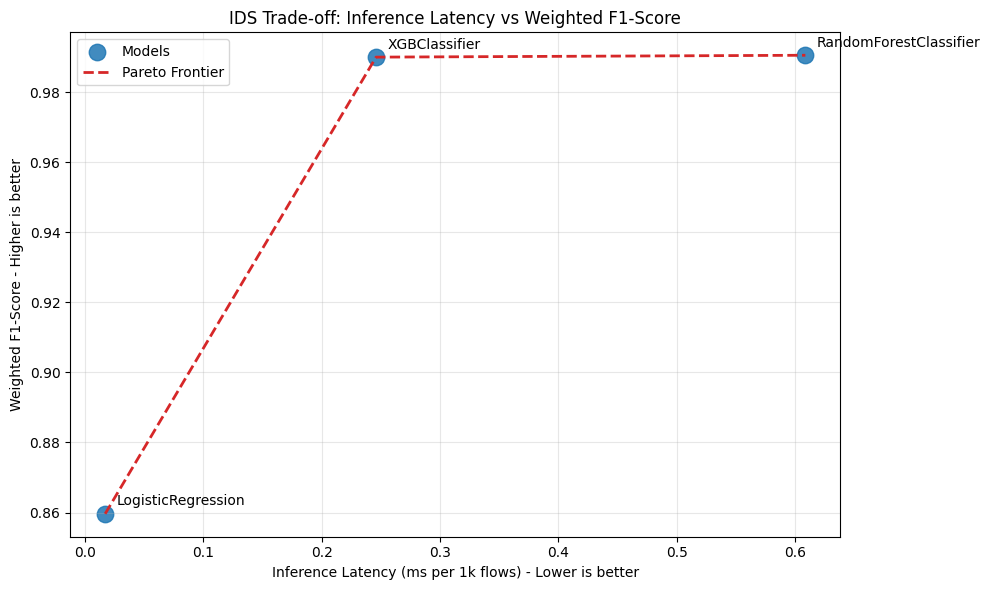


🏆 Top model by Weighted F1-Score: RandomForestClassifier


In [8]:
results_df = pd.DataFrame(results_records)
results_df = results_df.sort_values('Weighted F1-Score', ascending=False).reset_index(drop=True)

print("=" * 90)
print("Model Performance Summary (sorted by Weighted F1-Score)")
print("=" * 90)
print(results_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

lat_col = 'Inference Latency (ms per 1k flows)'
f1_col = 'Weighted F1-Score'

sorted_by_latency = results_df.sort_values(lat_col).reset_index(drop=True)
pareto_points = []
best_f1_so_far = -np.inf

for _, row in sorted_by_latency.iterrows():
    if row[f1_col] > best_f1_so_far:
        pareto_points.append({
            'Model': row['Model'],
            lat_col: row[lat_col],
            f1_col: row[f1_col],
        })
        best_f1_so_far = row[f1_col]

pareto_df = pd.DataFrame(pareto_points)

plt.figure(figsize=(10, 6))
plt.scatter(
    results_df[lat_col],
    results_df[f1_col],
    s=140,
    alpha=0.85,
    color='tab:blue',
    label='Models'
 )

for _, row in results_df.iterrows():
    plt.annotate(
        row['Model'],
        (row[lat_col], row[f1_col]),
        textcoords='offset points',
        xytext=(8, 6),
        ha='left'
    )

if len(pareto_df) >= 2:
    plt.plot(
        pareto_df[lat_col],
        pareto_df[f1_col],
        linestyle='--',
        linewidth=2,
        color='tab:red',
        label='Pareto Frontier'
    )

plt.title('IDS Trade-off: Inference Latency vs Weighted F1-Score')
plt.xlabel('Inference Latency (ms per 1k flows) - Lower is better')
plt.ylabel('Weighted F1-Score - Higher is better')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, 'Model']
print(f"\n🏆 Top model by Weighted F1-Score: {best_model_name}")

### Step 4: Export the Best Model

Select the model with the highest weighted F1-score, retrain it on the full scaled dataset, and save it to the `models/` directory.

In [9]:
best_model_name = results_df.loc[0, 'Model']
best_model = model_builders[best_model_name]()

# Retrain best model on all scaled data before export
best_model.fit(X_scaled, y)

model_path = os.path.join(MODELS_DIR, 'best_model.joblib')
joblib.dump(best_model, model_path)

print(f"🏆 Best model selected: {best_model_name}")
print(f"💾 Model saved to: {os.path.abspath(model_path)}")
print(f"   Model file size: {os.path.getsize(model_path) / 1024 / 1024:.1f} MB")

# Verify exported artifacts
print(f"\n📁 Files in models/ directory:")
for f in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, f)
    print(f"   {f} ({os.path.getsize(fpath) / 1024 / 1024:.1f} MB)")

print("\n🎉 Comparative training pipeline complete.")

🏆 Best model selected: RandomForestClassifier
💾 Model saved to: c:\Vault\Projects\network-security-project\models\best_model.joblib
   Model file size: 35.0 MB

📁 Files in models/ directory:
   best_model.joblib (35.0 MB)
   rf_model.joblib (30.7 MB)
   scaler.joblib (0.0 MB)

🎉 Comparative training pipeline complete.


### ⏸️ Checkpoint 2

**Review before moving on:**
- The performance table should list all three models sorted by weighted F1-score.
- The Pareto scatter plot should show each model annotated by name.
- `models/best_model.joblib` and `models/scaler.joblib` should both exist.

**Wait for confirmation** before proceeding to build the live Streamlit application.